## 1. Running distance measures

At each step \( t \), you compute a distance \( M_t \) between the *current embedding* and the *running (EMA) mean embedding*:

$$
M_t = \text{dist}\bigl(\text{tracker.mean}, \text{current\_embedding}\bigr).
$$

The specific function \( \text{dist}(\cdot) \) depends on the chosen metric (e.g., Euclidean, Chebyshev, etc.).

---

## 2. Rolling window of distances

You maintain a list \( \{M_1, M_2, \ldots, M_t\} \) of distances over time (across batches of data). For dynamic thresholding, you only use the most recent \( w \) values of this list (where \( w \) is `args.window_size`), i.e.,

$$
\bigl\{ M_{t-w+1}, M_{t-w+2}, \ldots, M_{t} \bigr\}.
$$

---

## 3. Mean and standard deviation within the window

You then compute:

- The rolling mean of the last \( w \) distances:

  $$
  \bar{M}_t = \frac{1}{w} \sum_{\tau = t-w+1}^t M_\tau.
  $$

- The rolling standard deviation of those same distances:

  $$
  \sigma_t = \sqrt{\frac{1}{w} \sum_{\tau=t-w+1}^t \bigl(M_\tau - \bar{M}_t\bigr)^2}.
  $$

---

## 4. Dynamic threshold definition

The threshold at time \( t \) is taken as:

$$
T_t = \bar{M}_t \;+\; (\text{drift\_threshold\_std}) \times \sigma_t,
$$

where `drift_threshold_std` is a hyperparameter (e.g., \( 3.0 \) standard deviations).

---

## 5. Drift detection criterion

Finally, drift is flagged whenever the current distance \( M_t \) **exceeds** the computed threshold \( T_t \):

$$
\text{Drift detected at time } t \quad \Longleftrightarrow \quad M_t > T_t.
$$

---

### Putting it all together

1. **Track distances**: For each batch \( t \), compute distance \( M_t \).
2. **Wait for enough data**: If \( t < w \), you cannot compute a rolling mean/std with \( w \) values yet, so you skip threshold checks (or store a placeholder).
3. **Compute rolling statistics**: Once you have at least \( w \) distance measurements, take the last \( w \) distances, calculate \( \bar{M}_t \) and \( \sigma_t \).
4. **Set threshold**: \( T_t = \bar{M}_t + k\,\sigma_t \), where \( k = \text{drift\_threshold\_std} \).
5. **Compare and detect drift**: If \( M_t > T_t \), you log a drift detection event.

This rolling approach ensures the threshold adapts dynamically to changes in the statistics of the recent distance values rather than being fixed.

/Users/jasper.bruin/Documents/driftwatch/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


choosing model: chebyshev
Using device: mps
Loading model and tokenizer...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/sec-bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model ready on device: mps
Original dataset loaded: 10000 WikiText samples
Financial dataset loaded: 4846 samples
Kaggle-like dataset loaded: 1000 samples
Simulated a single GRADUAL domain drift from 50% to 100% of data.
Starting drift detection...
Batch 90: Drift detected! chebyshev distance = 0.4789, threshold = 0.4729
Distances saved to results/distances.npy
Thresholds saved to results/thresholds.npy
Drift points saved to results/drift_points.npy


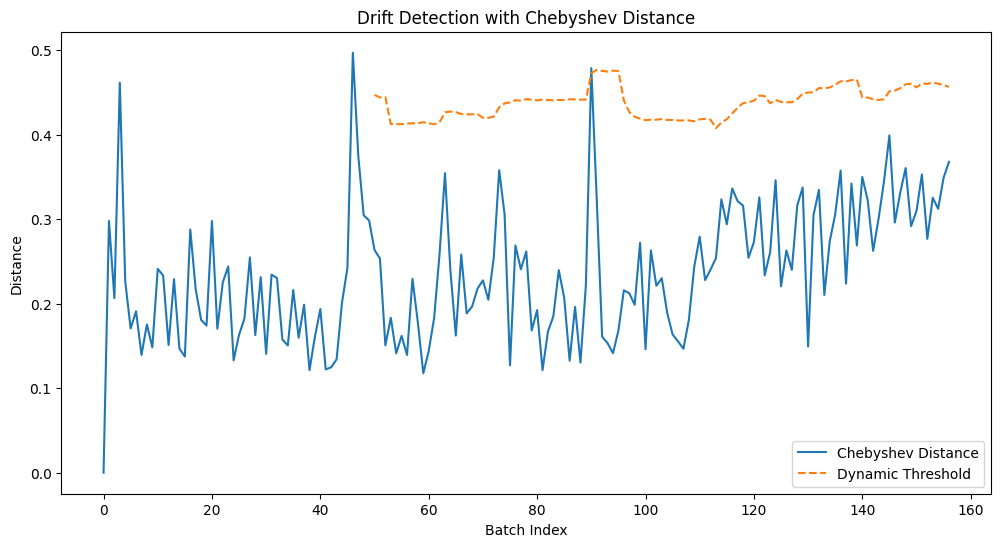

Plot saved to results/drift_detection_with_cls.png


In [1]:
import argparse
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
import matplotlib.pyplot as plt
import os
import random

###############################################################################
# 1) Parse Arguments
###############################################################################
def parse_args():
    parser = argparse.ArgumentParser(
        description="Run CLS token drift detection experiments with a true domain shift."
    )
    parser.add_argument("--model_name", type=str,
                        default="nlpaueb/sec-bert-base",
                        help="HuggingFace model name (SEC-BERT variant).")
    parser.add_argument("--wiki_dataset_name", type=str, default="wikitext",
                        help="HuggingFace dataset for original text.")
    parser.add_argument("--wiki_dataset_config", type=str,
                        default="wikitext-2-raw-v1", help="Dataset config.")
    parser.add_argument("--wiki_split", type=str, default="train",
                        help="WikiText dataset split.")
    parser.add_argument("--financial_dataset_name", type=str,
                        default="financial_phrasebank",
                        help="HuggingFace dataset for financial domain.")
    parser.add_argument("--financial_dataset_config", type=str,
                        default="sentences_50agree",
                        help="Configuration of financial_phrasebank.")
    parser.add_argument("--financial_split", type=str, default="train",
                        help="Financial dataset split.")
    parser.add_argument("--max_texts", type=int, default=10000,
                        help="Max number of texts to use from dataset.")
    parser.add_argument("--batch_size", type=int, default=64,
                        help="Batch size.")
    parser.add_argument("--alpha", type=float, default=0.01,
                        help="Alpha for running mean/cov updates.")
    parser.add_argument("--drift_threshold_std", type=float, default=3.0,
                        help="Number of std devs for threshold.")
    parser.add_argument("--window_size", type=int, default=50,
                        help="Rolling window size for threshold computation.")
    parser.add_argument("--output_dir", type=str, default="results",
                        help="Directory to save results and plots.")

    # New argument for distance metric
    parser.add_argument("--distance_metric",
                        type=str,
                        default="chebyshev",
                        choices=["mahalanobis", "euclidean", "manhattan",
                                 "minkowski", "chebyshev", "canberra"],
                        help="Distance metric to use for drift detection.")

    args, _ = parser.parse_known_args()
    return args

args = parse_args()

print(f"choosing model: {args.distance_metric}")

###############################################################################
# 2) Device Setup
###############################################################################
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

# Ensure output directory exists
os.makedirs(args.output_dir, exist_ok=True)

###############################################################################
# 3) Load Model and Tokenizer
###############################################################################
print("Loading model and tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(args.model_name)
model = AutoModelForSequenceClassification.from_pretrained(args.model_name)
model.to(device)
model.eval()
print("Model ready on device:", device)

###############################################################################
# 4) Load Original (WikiText) Dataset
###############################################################################
wiki_dataset = load_dataset(args.wiki_dataset_name,
                            args.wiki_dataset_config,
                            split=args.wiki_split)
texts = wiki_dataset["text"]

if args.max_texts > 0 and args.max_texts < len(texts):
    texts = texts[:args.max_texts]
print(f"Original dataset loaded: {len(texts)} WikiText samples")

###############################################################################
# 5) Load Financial Dataset for Drift
###############################################################################
fin_dataset = load_dataset(args.financial_dataset_name,
                           args.financial_dataset_config,
                           split=args.financial_split)
financial_texts = fin_dataset["sentence"]
random.shuffle(financial_texts)

# Simulate a second domain with "Kaggle-like" data
kaggle_texts = financial_texts[:1000]
print(f"Financial dataset loaded: {len(financial_texts)} samples")
print(f"Kaggle-like dataset loaded: {len(kaggle_texts)} samples")

###############################################################################
# 6) Simulate a Single Gradual Domain Drift in the Last 50%
###############################################################################
n = len(texts)

# We keep indices [0 : n//2] as plain WikiText
# Then from [n//2 : n], we gradually replace WikiText with Finance text

drift_start = n // 2  # 50% point
drift_end   = n       # end of dataset

fin_idx = 0

for i in range(drift_start, drift_end):
    # fraction goes from 0.0 (at drift_start) to 1.0 (at drift_end)
    fraction = (i - drift_start) / (drift_end - drift_start)

    # With 'fraction' probability, replace with financial text
    if random.random() < fraction:
        # Cycle through financial_texts if needed
        if fin_idx >= len(financial_texts):
            fin_idx = 0
        texts[i] = financial_texts[fin_idx]
        fin_idx += 1
    else:
        # Otherwise, keep the original WikiText
        pass

print("Simulated a single GRADUAL domain drift from 50% to 100% of data.")




###############################################################################
# 7) Utility Functions
###############################################################################
def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i:i + batch_size]

def extract_cls_embeddings(model, tokenizer, texts, device):
    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        # For SEC-BERT or BERT-based model for sequence classification,
        # the transformer backbone is typically model.bert
        outputs = model.bert(input_ids, attention_mask=attention_mask)
        # [CLS] token is at index 0
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    # Return the average embedding across the batch to reduce noise
    return cls_embeddings.mean(dim=0).cpu().numpy()

###############################################################################
# 8) Vector/Feature-Space Distance Functions
###############################################################################
def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y) ** 2))

def manhattan_distance(x, y):
    return np.sum(np.abs(x - y))

def minkowski_distance(x, y, p=3):
    return np.sum(np.abs(x - y) ** p) ** (1.0 / p)

def chebyshev_distance(x, y):
    return np.max(np.abs(x - y))

def canberra_distance(x, y):
    numerator = np.abs(x - y)
    denominator = np.abs(x) + np.abs(y) + 1e-12
    return np.sum(numerator / denominator)

DISTANCE_FUNCTIONS = {
    "euclidean": euclidean_distance,
    "manhattan": manhattan_distance,
    "minkowski": lambda u, v: minkowski_distance(u, v, p=3),  # example p=3
    "chebyshev": chebyshev_distance,
    "canberra": canberra_distance,
}

###############################################################################
# 9) EmbeddingTracker Class
###############################################################################
class EmbeddingTracker:
    """
    A tracker that maintains:
    - An exponential-moving-average (EMA) of the embedding mean
    - An exponential-moving-average covariance (for Mahalanobis)
    - A selected distance metric from DISTANCE_FUNCTIONS
    """
    def __init__(self, embedding_dim, alpha=0.01, distance_name="mahalanobis"):
        self.alpha = alpha
        self.distance_name = distance_name

        # Keep track of the mean for all distance types
        self.mean = np.zeros((embedding_dim,))
        self.count = 0

        # Only used for Mahalanobis
        self.cov = np.eye(embedding_dim)

    def update(self, embedding):
        """Update the running mean (and covariance, if Mahalanobis)."""
        if self.count == 0:
            self.mean = embedding
            if self.distance_name == "mahalanobis":
                self.cov = np.eye(len(embedding))
        else:
            # Update mean (EMA)
            self.mean = (1 - self.alpha) * self.mean + self.alpha * embedding

            # Update covariance if we're doing Mahalanobis
            if self.distance_name == "mahalanobis":
                diff = embedding - self.mean
                self.cov = (1 - self.alpha) * self.cov + self.alpha * np.outer(diff, diff)
        self.count += 1

    def compute_distance(self, embedding):
        """Compute distance between 'embedding' and the tracker's current mean."""
        if self.distance_name == "mahalanobis":
            diff = embedding - self.mean
            cov_inv = np.linalg.pinv(self.cov)
            return np.sqrt(diff.T @ cov_inv @ diff)
        else:
            dist_fn = DISTANCE_FUNCTIONS[self.distance_name]
            return dist_fn(self.mean, embedding)

###############################################################################
# 10) Main Experiment Loop: Drift Detection
###############################################################################
print("Starting drift detection...")

# Get a dummy embedding to initialize tracker dimensions
dummy_embedding = extract_cls_embeddings(model, tokenizer, ["Hello world!"], device)
embedding_dim = len(dummy_embedding)

# Create the tracker, picking up the distance metric from args
tracker = EmbeddingTracker(embedding_dim,
                           alpha=args.alpha,
                           distance_name=args.distance_metric)

distances = []
thresholds = []
drift_points = []  # Store batch indices where drifts are detected

for batch_index, batch_texts in enumerate(batch_generator(texts, batch_size=args.batch_size)):
    current_embedding = extract_cls_embeddings(model, tokenizer, batch_texts, device)
    tracker.update(current_embedding)
    # Use our flexible compute_distance method
    M_t = tracker.compute_distance(current_embedding)

    distances.append(M_t)

    # Compute threshold after enough history
    if len(distances) > args.window_size:
        recent_dists = distances[-args.window_size:]
        mean_dist = np.mean(recent_dists)
        std_dist = np.std(recent_dists)
        threshold = mean_dist + args.drift_threshold_std * std_dist
        thresholds.append(threshold)

        if M_t > threshold:
            print(
                f"Batch {batch_index}: Drift detected! "
                f"{args.distance_metric} distance = {M_t:.4f}, "
                f"threshold = {threshold:.4f}"
            )
            drift_points.append(batch_index)
    else:
        # Not enough history, we just record a placeholder
        thresholds.append(float('inf'))

###############################################################################
# 11) Save Results
###############################################################################
distances_path = os.path.join(args.output_dir, "distances.npy")
thresholds_path = os.path.join(args.output_dir, "thresholds.npy")
drift_points_path = os.path.join(args.output_dir, "drift_points.npy")

np.save(distances_path, distances)
np.save(thresholds_path, thresholds)
np.save(drift_points_path, drift_points)

print(f"Distances saved to {distances_path}")
print(f"Thresholds saved to {thresholds_path}")
print(f"Drift points saved to {drift_points_path}")

###############################################################################
# 12) Visualization
###############################################################################
plt.figure(figsize=(12, 6))
plt.plot(distances, label=f"{args.distance_metric.capitalize()} Distance")
plt.plot(thresholds, label="Dynamic Threshold", linestyle="--")

plt.xlabel("Batch Index")
plt.ylabel("Distance")
plt.title(f"Drift Detection with {args.distance_metric.capitalize()} Distance")
plt.legend()

plot_path = os.path.join(args.output_dir, "drift_detection_with_cls.png")
plt.savefig(plot_path)
plt.show()
print(f"Plot saved to {plot_path}")